In [ ]:
!pip install kagglehub -q

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

In [ ]:
path = kagglehub.dataset_download(
    "robikscube/hourly-energy-consumption"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'hourly-energy-consumption' dataset.
Dataset Path: /kaggle/input/hourly-energy-consumption


In [ ]:
files = os.listdir(path)

for file in files:
    print(file)

est_hourly.paruqet
DOM_hourly.csv
EKPC_hourly.csv
DUQ_hourly.csv
DAYTON_hourly.csv
PJME_hourly.csv
PJM_Load_hourly.csv
NI_hourly.csv
FE_hourly.csv
COMED_hourly.csv
AEP_hourly.csv
pjm_hourly_est.csv
DEOK_hourly.csv
PJMW_hourly.csv


In [ ]:
file_path = os.path.join(path, "AEP_hourly.csv")

df = pd.read_csv(file_path)

df.head()

NameError: name 'os' is not defined

In [ ]:
print(df.shape)

df.info()

df.describe()

(121273, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.sort_values('Datetime')

df.set_index('Datetime', inplace=True)

df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


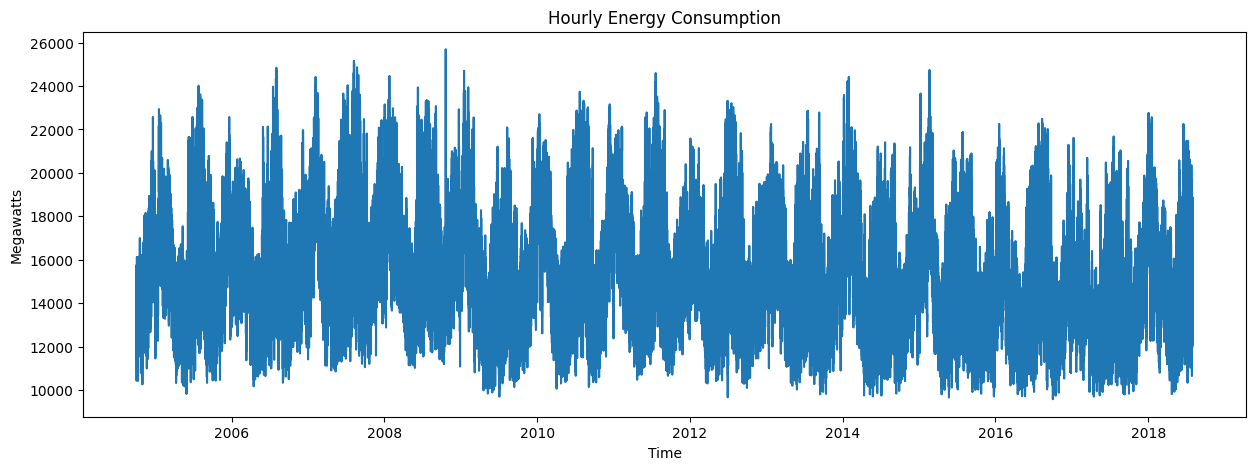

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['AEP_MW'])
plt.title("Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Megawatts")
plt.show()

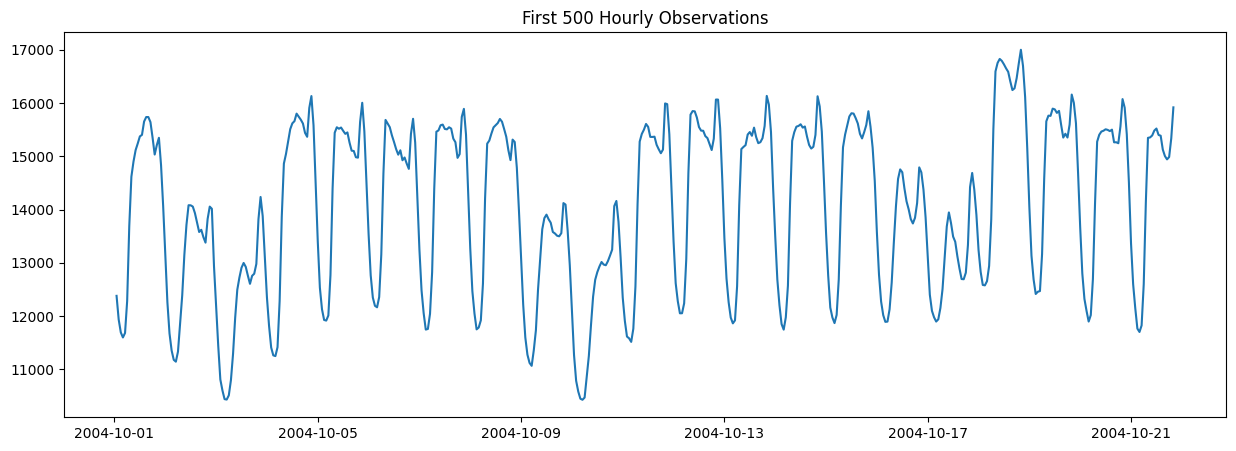

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['AEP_MW'][:500])
plt.title("First 500 Hourly Observations")
plt.show()

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df[['AEP_MW']]
)

scaled_data[:5]

array([[0.17363783],
       [0.14608415],
       [0.1310041 ],
       [0.1251086 ],
       [0.13032146]])

In [ ]:
train_size = int(len(scaled_data)*0.70)

val_size = int(len(scaled_data)*0.15)

train = scaled_data[:train_size]

val = scaled_data[
    train_size:
    train_size+val_size
]

test = scaled_data[
    train_size+val_size:
]

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (84891, 1)
Validation: (18190, 1)
Test: (18192, 1)


In [ ]:
sequence_length = 24

batch_size = 32

train_gen = TimeseriesGenerator(
    train,
    train,
    length=sequence_length,
    batch_size=batch_size
)

val_gen = TimeseriesGenerator(
    val,
    val,
    length=sequence_length,
    batch_size=batch_size
)

test_gen = TimeseriesGenerator(
    test,
    test,
    length=sequence_length,
    batch_size=batch_size
)

In [ ]:
rnn_model = Sequential([
    SimpleRNN(
        50,
        activation='tanh',
        input_shape=(sequence_length,1)
    ),
    Dense(1)
])
rnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()
rnn_history = rnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)
rnn_time = time.time()-start

Epoch 1/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 7.4057e-04 - mae: 0.0178 - val_loss: 1.9941e-04 - val_mae: 0.0105
Epoch 2/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 2.7877e-04 - mae: 0.0121 - val_loss: 1.9420e-04 - val_mae: 0.0102
Epoch 3/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 2.7656e-04 - mae: 0.0121 - val_loss: 1.9620e-04 - val_mae: 0.0101
Epoch 4/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 2.8987e-04 - mae: 0.0123 - val_loss: 2.0287e-04 - val_mae: 0.0104
Epoch 5/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 2.9468e-04 - mae: 0.0124 - val_loss: 2.1242e-04 - val_mae: 0.0107
Epoch 6/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 2.9169e-04 - mae: 0.0124 - val_loss: 2.3825e-04 - val_mae: 0.0119
Epoch 7/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 2.8506e-04 - mae: 0.0122 - val_loss: 2.2885e-04 - val_mae: 0.0113
Epoch 8/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 2.8001e-04 - mae: 0.0121 - val_los

In [ ]:
lstm_model = Sequential([
    LSTM(
        50,
        input_shape=(sequence_length,1)
    ),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

lstm_history = lstm_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

lstm_time = time.time()-start

Epoch 1/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 0.0033 - mae: 0.0376 - val_loss: 8.6635e-04 - val_mae: 0.0225
Epoch 2/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5.3416e-04 - mae: 0.0175 - val_loss: 2.7702e-04 - val_mae: 0.0124
Epoch 3/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 3.7589e-04 - mae: 0.0144 - val_loss: 5.0670e-04 - val_mae: 0.0189
Epoch 4/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 3.2387e-04 - mae: 0.0133 - val_loss: 2.1939e-04 - val_mae: 0.0109
Epoch 5/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 2.9341e-04 - mae: 0.0126 - val_loss: 2.3685e-04 - val_mae: 0.0119
Epoch 6/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 2.6759e-04 - mae: 0.0120 - val_loss: 2.2793e-04 - val_mae: 0.0115
Epoch 7/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 2.3434e-04 - mae: 0.0112 - val_loss: 1.6964e-04 - val_mae: 0.0095
Epoch 8/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 2.1507e-04 - mae: 0.0107 - val

In [ ]:
gru_model = Sequential([
    GRU(
        50,
        input_shape=(sequence_length,1)
    ),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()

gru_history = gru_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

gru_time = time.time()-start

Epoch 1/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 52s 19ms/step - loss: 0.0017 - mae: 0.0262 - val_loss: 3.4751e-04 - val_mae: 0.0137
Epoch 2/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 49s 18ms/step - loss: 4.0035e-04 - mae: 0.0146 - val_loss: 2.9765e-04 - val_mae: 0.0127
Epoch 3/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 46s 17ms/step - loss: 4.0111e-04 - mae: 0.0144 - val_loss: 2.7123e-04 - val_mae: 0.0121
Epoch 4/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 50s 19ms/step - loss: 3.5882e-04 - mae: 0.0138 - val_loss: 2.7734e-04 - val_mae: 0.0129
Epoch 5/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 46s 17ms/step - loss: 3.0120e-04 - mae: 0.0126 - val_loss: 2.2383e-04 - val_mae: 0.0115
Epoch 6/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 48s 18ms/step - loss: 2.5338e-04 - mae: 0.0115 - val_loss: 1.7453e-04 - val_mae: 0.0097
Epoch 7/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 2.2635e-04 - mae: 0.0109 - val_loss: 1.5926e-04 - val_mae: 0.0093
Epoch 8/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 2.0950e-04 - mae: 0.0105 - val

In [ ]:
rnn_loss, rnn_mae = rnn_model.evaluate(test_gen)

lstm_loss, lstm_mae = lstm_model.evaluate(test_gen)

gru_loss, gru_mae = gru_model.evaluate(test_gen)

568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.7913e-04 - mae: 0.0104
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.3268e-04 - mae: 0.0085
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.3037e-04 - mae: 0.0085


In [ ]:
results = pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Loss':[rnn_loss,lstm_loss,gru_loss],
    'MAE':[rnn_mae,lstm_mae,gru_mae],
    'Training Time':[rnn_time,lstm_time,gru_time]
})

results

,Model,Loss,MAE,Training Time
0,RNN,0.000179,0.010384,194.680851
1,LSTM,0.000133,0.008524,391.777781
2,GRU,0.000130,0.008496,501.087773


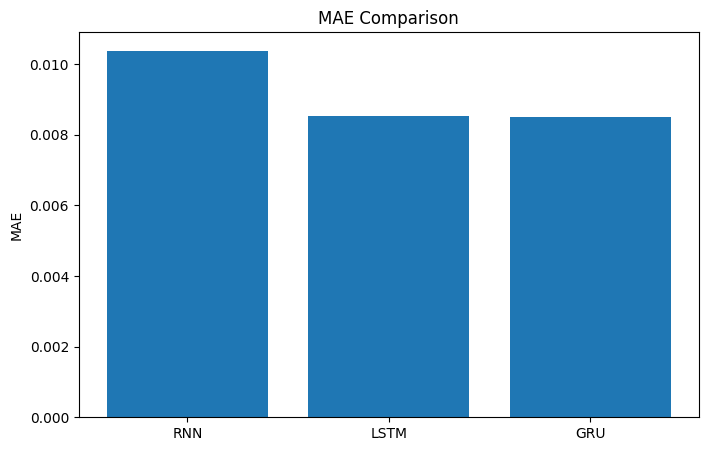

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    results['Model'],
    results['MAE']
)
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()

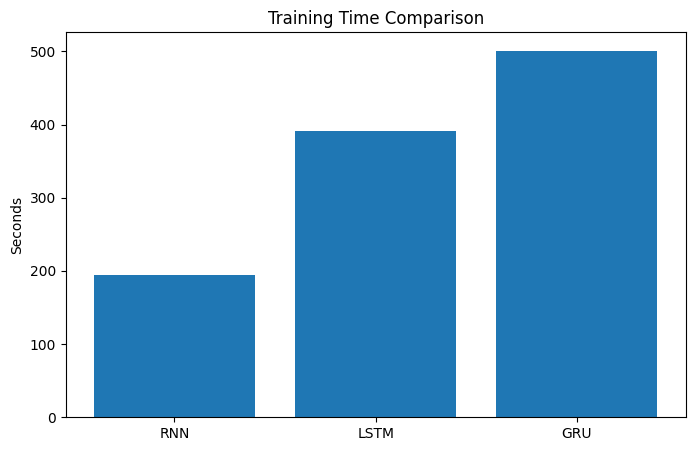

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    results['Model'],
    results['Training Time']
)
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

In [ ]:
rnn_predictions = rnn_model.predict(test_gen)

rnn_predictions = scaler.inverse_transform(
    rnn_predictions
)

568/568 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


In [ ]:
lstm_predictions = lstm_model.predict(
    test_gen
)

lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [ ]:
gru_predictions = gru_model.predict(
    test_gen
)

gru_predictions = scaler.inverse_transform(
    gru_predictions
)

568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [ ]:
actual = scaler.inverse_transform(
    test[sequence_length:]
)

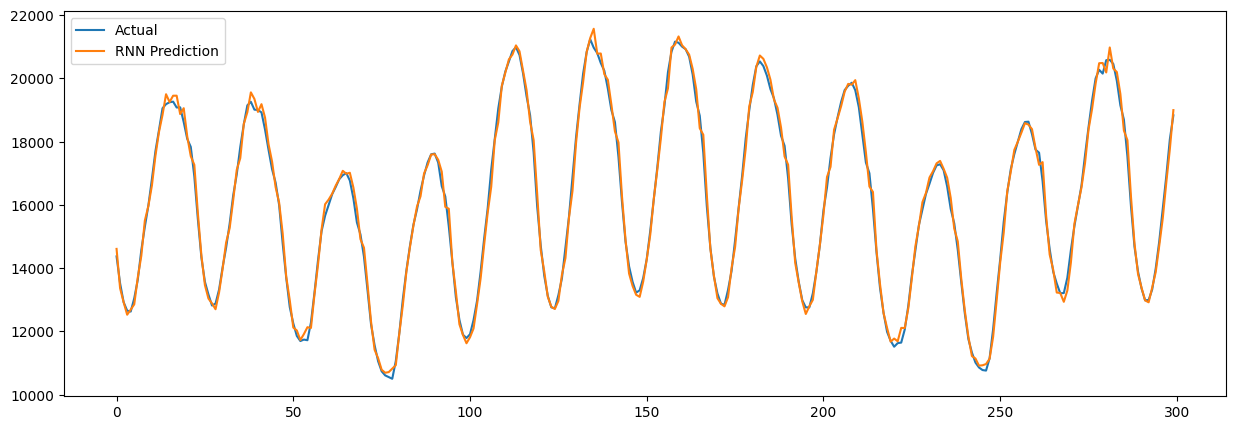

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(
    actual[:300],
    label="Actual"
)
plt.plot(
    rnn_predictions[:300],
    label="RNN Prediction"
)
plt.legend()
plt.show()

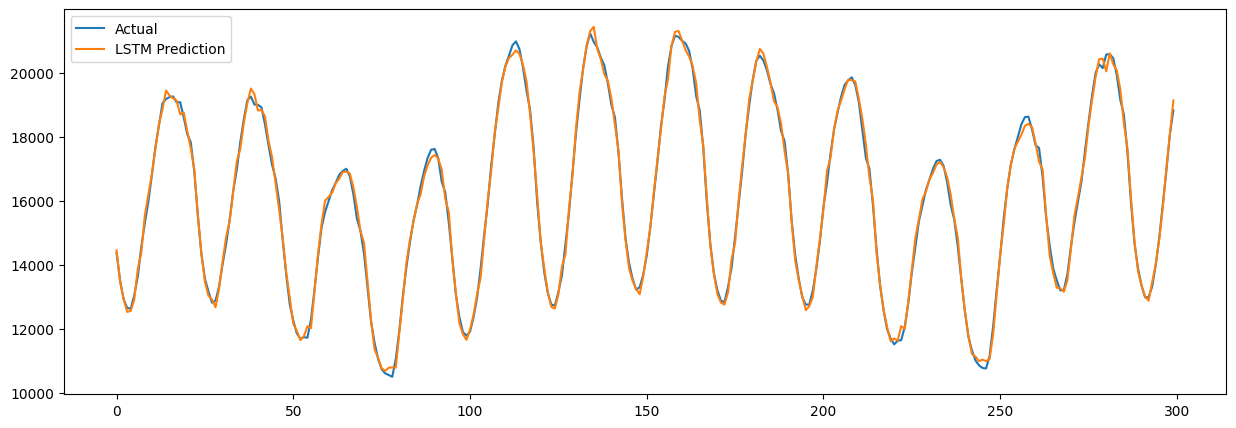

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(
    actual[:300],
    label="Actual"
)
plt.plot(
    lstm_predictions[:300],
    label="LSTM Prediction"
)
plt.legend()
plt.show()

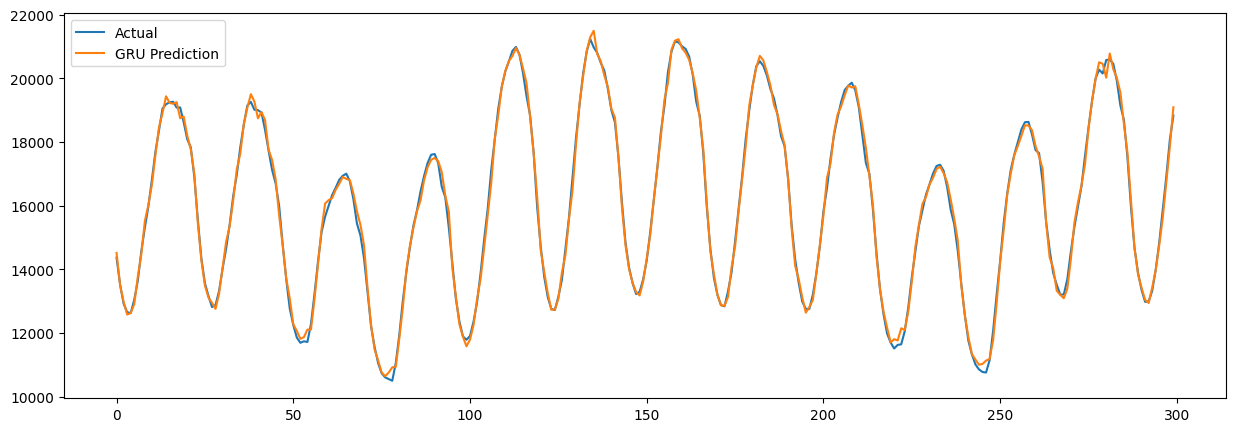

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(
    actual[:300],
    label="Actual"
)
plt.plot(
    gru_predictions[:300],
    label="GRU Prediction"
)
plt.legend()
plt.show()